# 04 · Uncertainty experiments

Nine synthetic daily series with known error structure, each fitted with the same MLP-based
`GPURegressor`, to see how the predictive distribution adapts.

| test | series | input |
|---|---|---|
| T1 | Uniform(100, 1100) noise, no signal | season |
| T2 | `5 + sin` season + Uniform(-2, 2) | season |
| T3 | `100 + sin` season + Normal(0, 1) | season |
| T4 | `100·sin` season + Normal error, heteroscedastic | season |
| T5 | `100·sin` season + log-normal error | season |
| T6 | `100·sin` season + log-normal error, heteroscedastic | season |
| T7 | AR(1), `0.9·y[t-1]` + Uniform(-3, 3) | previous day |
| T8 | AR(2), `0.45·y[t-1] + 0.5·y[t-2]` + Normal(0, 1) | previous day |

*season* = sine and cosine of the day of year; *previous day* = the observed value one day
earlier. `N_YEARS` sets the record length; the first half trains, the second half validates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import MLPModel
from foresight_gpu.metrics.probabilistic import reliability
from foresight_gpu.utils import plot_timeseries, plot_qq

START, N_YEARS = '1964-10-01', 4          # change N_YEARS for a longer record
rng = np.random.default_rng(0)

### Test generators

Each takes an empty daily frame with one column, `Sample`, and returns the synthetic series.

In [2]:
def empty_record(start=START, n_years=N_YEARS):
    end = pd.Timestamp(start) + pd.DateOffset(years=n_years) - pd.Timedelta(days=1)
    return pd.DataFrame({'Sample': np.nan}, index=pd.date_range(start, end, freq='D'))


def season(x):
    return np.sin(2 * np.pi * x.index.day_of_year / 365)


def error_generate(x, heteroscedasticity=None, fun=rng.normal, fun_params={'loc': 0, 'scale': 1}):
    """Add errors drawn from `fun`; heteroscedastic errors scale with the signal."""
    y = x.copy()
    error = fun(**fun_params, size=y.shape[0])
    if heteroscedasticity:
        y.iloc[:, 0] += error * heteroscedasticity * x.values.ravel()
    else:
        y.iloc[:, 0] += error
    return y


def T1(x, c=100, r=1000):
    y = x.copy()
    y['Sample'] = rng.random(x.shape[0]) * r + c
    return y


def T2(x, r=2):
    y = x.copy()
    y['Sample'] = 5 + season(x) + rng.uniform(-r, r, size=x.shape[0])
    return y


def T3(x):
    y = x.copy()
    y['Sample'] = 100 + season(x)
    return error_generate(y)


def T4(x, h=0.5):
    y = x.copy()
    y['Sample'] = 100 * season(x)
    y = error_generate(y, heteroscedasticity=h)
    y['Sample'] -= y['Sample'].min()
    return y


def T5(x):
    y = x.copy()
    y['Sample'] = 100 * season(x)
    y = error_generate(y, fun=rng.lognormal, fun_params=dict(mean=0, sigma=0.5))
    y['Sample'] -= y['Sample'].min()
    return y


def T6(x, h=0.5):
    y = x.copy()
    y['Sample'] = 100 * season(x)
    y = error_generate(y, heteroscedasticity=h, fun=rng.lognormal,
                       fun_params=dict(mean=0, sigma=0.5))
    y['Sample'] -= y['Sample'].min()
    return y


def T7(x, ini=1, c1=0, c2=0.9, variance=(-3, 3)):
    y = x.copy()
    tmp = np.empty(y.shape[0])
    tmp[0] = ini + c1
    for i in range(1, tmp.size):
        tmp[i] = tmp[i - 1] * c2 + c1 + rng.uniform(*variance)
    y['Sample'] = tmp
    return y


def T8(x, ini=(0, 0), c1=0.5, c2=0.45):
    y = x.copy()
    tmp = np.empty(y.shape[0])
    tmp[:2] = ini
    for i in range(2, tmp.size):
        tmp[i] = tmp[i - 1] * c2 + tmp[i - 2] * c1 + rng.standard_normal()
    y['Sample'] = tmp
    return y

### Model inputs

In [3]:
def cycle(targets):
    """Season as input: sine and cosine of the day of year."""
    doy = targets.index.day_of_year
    return pd.DataFrame({'Sin': np.sin(2 * np.pi * doy / 365),
                         'Cos': np.cos(2 * np.pi * doy / 365)}, index=targets.index)


def target(targets, leadtime=1):
    """Previous observed value as input (first `leadtime` rows are NaN)."""
    return targets.shift(leadtime).rename(columns={'Sample': 'targets'})


experiments = {
    'T1': (T1, cycle), 'T2': (T2, cycle), 'T3': (T3, cycle),
    'T4': (T4, cycle), 'T5': (T5, cycle), 'T6': (T6, cycle),
    'T7': (T7, target), 'T8': (T8, target),
}

### Run the experiments

Inputs are standardised with the training statistics (the estimator scales nothing), and the
MLP is given the training target's scale.

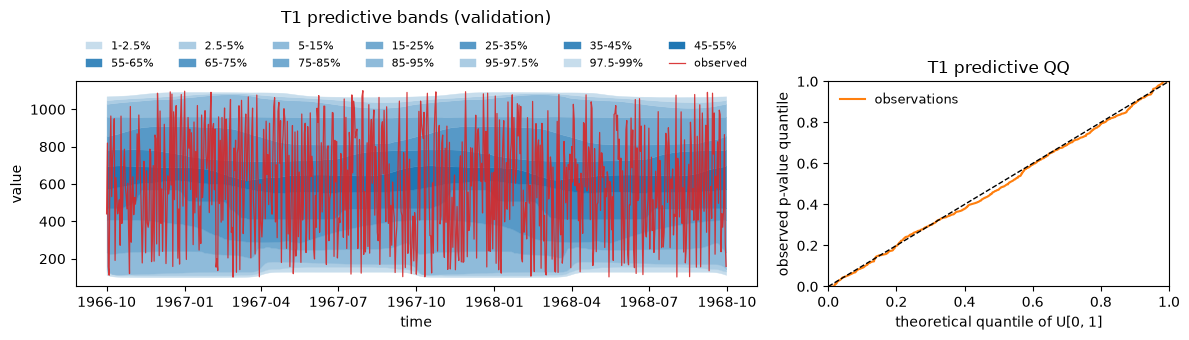

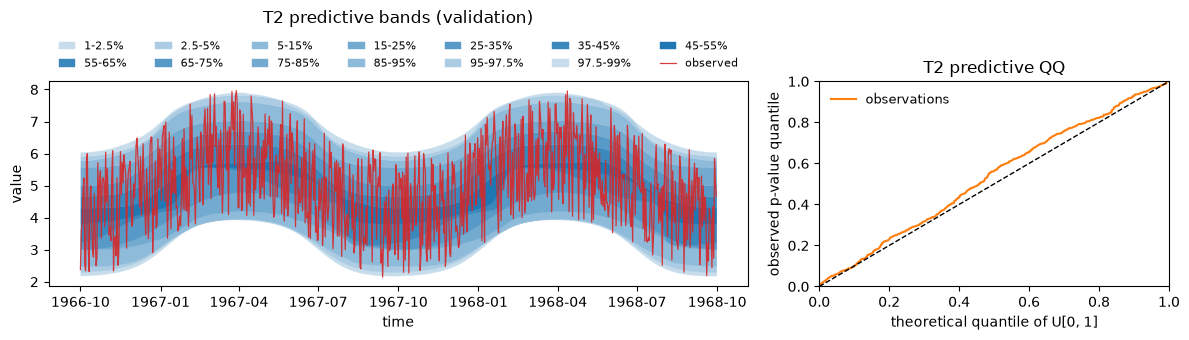

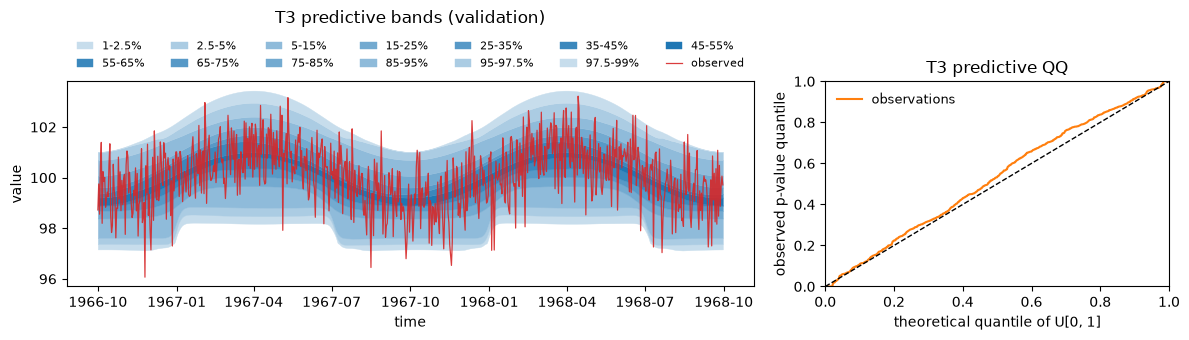

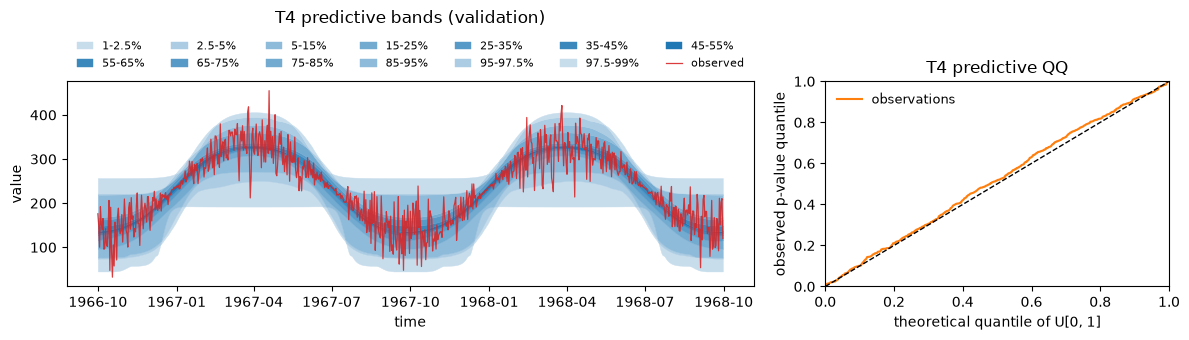

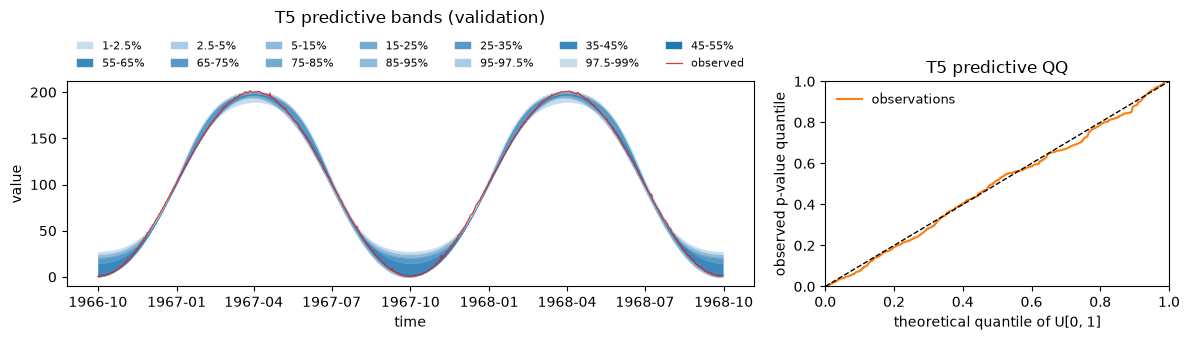

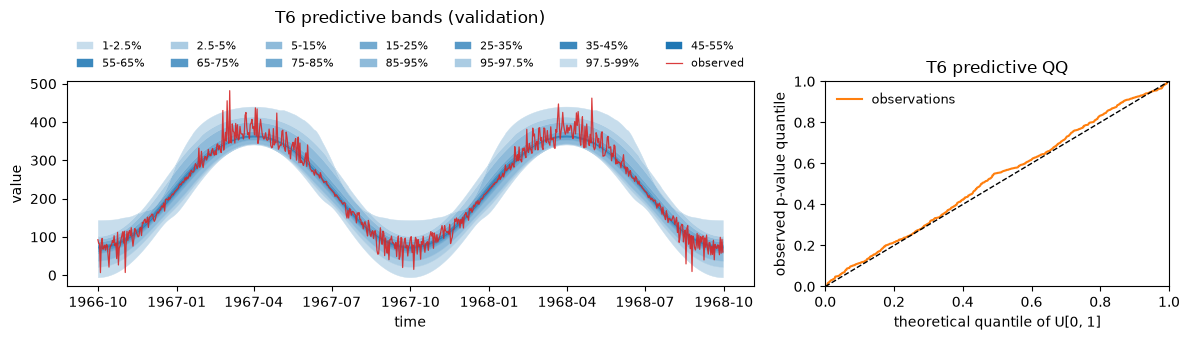

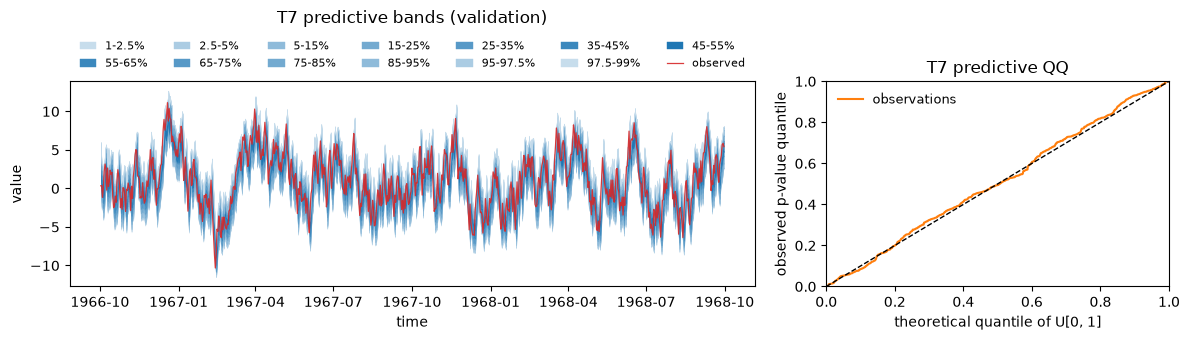

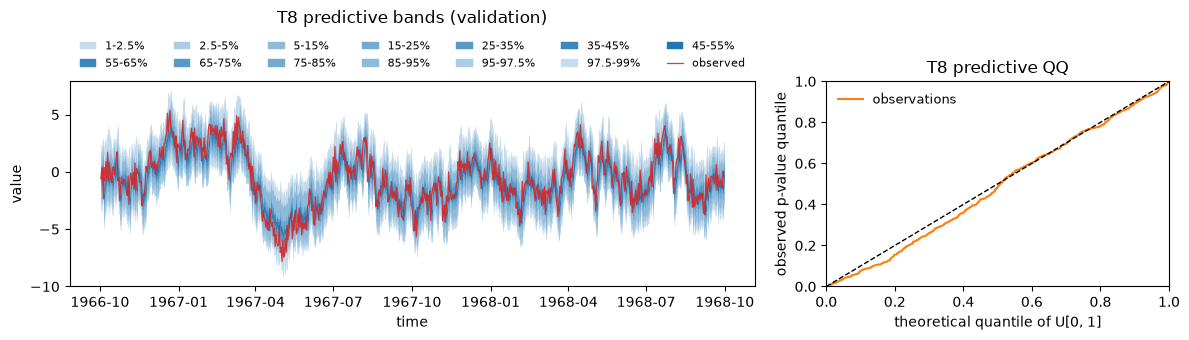

In [5]:
summary = {}
for name, (generate, make_input) in experiments.items():
    y = generate(empty_record())
    X = make_input(y)
    keep = X.notna().all(axis=1)
    X, y = X[keep], y.loc[keep, 'Sample']

    split = X.index[0] + (X.index[-1] - X.index[0]) / 2
    train, val = X.index < split, X.index >= split
    X = (X - X[train].mean()) / X[train].std()

    model = MLPModel(n_hidden=5, output_scale=y[train].std(), output_offset=y[train].mean())
    gpu = GPURegressor(model=model, metric='mae', population=800, n_iter=200, random_state=0)
    gpu.fit(X[train], y[train])

    bands = gpu.predict_quantiles(X[val])
    pvalues = gpu.predictive_pvalues(X[val], y[val])
    summary[name] = {'train alpha': reliability(gpu.predictive_pvalues(X[train], y[train])),
                     'validation alpha': reliability(pvalues)}

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={'width_ratios': [2, 1]})
    plot_timeseries(bands, gpu.ensemble_.quantiles, observed=y[val], index=y[val].index, ax=a0, color='C0')
    a0.set_title(f'{name} predictive bands (validation)', pad=42)
    plot_qq(pvalues, ax=a1)
    a1.set_title(f'{name} predictive QQ')
    fig.tight_layout()
    plt.show()

### Summary

Reliability `alpha` (1 = perfectly reliable) on the training and validation halves.

In [ ]:
pd.DataFrame(summary).T.round(3)

,train alpha,validation alpha
T1,0.984,0.949
T2,0.981,0.933
T3,0.986,0.962
T4,0.987,0.973
T5,0.941,0.940
T6,0.978,0.942
T7,0.985,0.113
T8,0.983,0.951
T9,0.989,0.934
